In [1]:
print("ok")

ok


In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [4]:
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY is missing from .env")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
chat_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
# chat_llm = ChatGoogleGenerativeAI(model = "gemini-3-flash-preview")

In [ ]:
chat_llm.invoke("Hello, how are you?").contentz

[{'type': 'text',
  'text': "Hello! I'm doing well, thank you for asking. How are you doing today? Is there anything I can help you with?",
  'extras': {'signature': 'EuoCCucCAb4+9vth7KOLUCL+sf/mf0lBffDcNyFeNg2FeR0E3Q5uLnXrL+ycXTiaoZlJt9Wg1gL9uCN4tkNna/RCrMHDvHiQU+V3qBUonob3nskbsagSnHPcprcQThDuL0HPvFSf7snClAEJYbZ5um0oVueEus02OM7fWqhbz71AWzbM/Myq8DpTmI/u7QQmWrxji3yA3SdDC08BdwbuXSX8FSKGNqbp5SKJnxUitvAu7AAHT3PSGBc7EbloxUsnjEKW/UvVyPPrFcgy/BnO99Xc0lMO25yNH4+gBv2MSfrM8pQ9LPaBYf+EGy3kR94/DKNiHHU5K5PMR2ocQO++doqC1SxOZYv2cnDTAHM4v/BbSnNhhFKWWkJZKZHFIWG5Xzd8jzTO4dtjH0WPduK17Aimcf0kac2HnxG7ZcdcyGJMmsNdL9whEZUurAPtY1H+W4o1LvwZ0uqntNpeTgDc80MoQhvHR4SCVw3lciM='}}]

In [8]:
from typing_extensions import TypedDict, Annotated
import operator

In [9]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [10]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [11]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])
    return{
        "messages":[response]
    }

In [12]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    # Handle both string and list content
    if isinstance(text, list):
        text = str(text)
    token_number = len(text.split())
    summary = f"Total tokens in generates answer: {token_number}"
    return{
        "messages":[AIMessage(content=summary)]
    }

In [13]:
from langgraph.graph import StateGraph

In [14]:
builder = StateGraph(GraphState)

In [15]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [16]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_counter")
builder.set_finish_point("token_counter")

In [17]:
app = builder.compile()

In [18]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [19]:
from IPython.display import Image, display

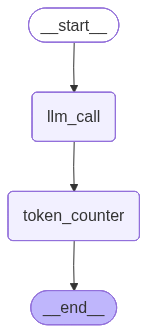

In [20]:
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
result = app.invoke({
    "messages":[HumanMessage(content="Hi,Tell me what are AI agents.")]
})

In [22]:
result

{'messages': [HumanMessage(content='Hi,Tell me what are AI agents.', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'text', 'text': 'To understand what **AI Agents** are, it helps to think of them as the next step in the evolution of artificial intelligence.\n\nWhile a standard AI (like a basic chatbot) **answers questions**, an AI Agent **performs tasks.**\n\nHere is a breakdown of what they are, how they work, and why they are different from the AI we’ve used so far.\n\n---\n\n### 1. The Basic Definition\nAn **AI Agent** is a software program that uses an AI model (like GPT-4) as its "brain" to perceive its environment, reason through problems, and take independent actions to achieve a specific goal.\n\n**The simplest analogy:** \n*   **Standard AI (LLM):** Is like a very smart book. You ask it a question, and it gives you information.\n*   **AI Agent:** Is like a digital employee. You give it a goal, and it uses tools to go and get the job done.\n\n---\n\

In [23]:
for m in result["messages"]:
    print(type(m).__name__,":",m.content)

HumanMessage : Hi,Tell me what are AI agents.
AIMessage : [{'type': 'text', 'text': 'To understand what **AI Agents** are, it helps to think of them as the next step in the evolution of artificial intelligence.\n\nWhile a standard AI (like a basic chatbot) **answers questions**, an AI Agent **performs tasks.**\n\nHere is a breakdown of what they are, how they work, and why they are different from the AI we’ve used so far.\n\n---\n\n### 1. The Basic Definition\nAn **AI Agent** is a software program that uses an AI model (like GPT-4) as its "brain" to perceive its environment, reason through problems, and take independent actions to achieve a specific goal.\n\n**The simplest analogy:** \n*   **Standard AI (LLM):** Is like a very smart book. You ask it a question, and it gives you information.\n*   **AI Agent:** Is like a digital employee. You give it a goal, and it uses tools to go and get the job done.\n\n---\n\n### 2. The Four Pillars of an Agent\nTo be considered an "agent," the syste

In [1]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [4]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=300)

In [5]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [ ]:
wiki_tool.run({"query":"What are AI agents?"})